# FASTQ data analysis - Foreign DNA identification
FASTQ files are the result of the sequencing of part of the exoma located on chromosome 11 (data were taken from samples of the 1000 Genomes project).

Steps:
 1. Perform the quality control of FASTQ files using FastQC tool. 

 2. Map sequenced readings to the hg38 reference genome using the BWA Mem tool. Using the python pysam library, specify the following:
2a. How many reads have been successfully mapped?
2b. How many pairs of reads are mapped so that both pairs are mapped?
2c. Draw a histogram of the lengths of the sequenced fragments (template_length)

 3. Process the obtained BAM file according to the GATK protocol (Duplicate marking, recalibration of base quality) 3a. What are the estimated PCRs and optical duplicates?

 4. Identify mutations using the Haplotype Caller tool and filter mutations with predefined filters (hard filtering) according to Broad recommendations. 4a. How many mutations are identified in total, how many SNPs, how many INDELs? 4b. How many mutations pass, and how many do not pass the filtering criteria? 4c. Calculate Ti/Tv ratio before and after filtration.

 5. Annotate mutations with the Funcotator tool 5a. Enumerate different values of ClinVar significance (annotation ClinVar_VCF_CLNSIG, how many mutations are marked as Benign, Likely_benign, etc).

 6. All samples contain a certain amount of DNA contamination with material of bacterial or viral origin. Most of these reads will not be mapped to the human genome. Extract readings that are not mapped in the mapping process, assemble them with the abyss tool, and identify the organism from which the longest scaffold originates using the Blast tool.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
root_dir =  '/content/'
tools_dir =  '/content/tools/'
drive_dir = '/content/drive/My\ Drive/bioinformatika/D2/'
data_dir = '/content/drive/My\ Drive/bioinformatika/D2/data/'
bwa_dir = '/content/tools/bwa/'

!mkdir -p {tools_dir}
%cd {drive_dir}

exome_sample_1 = 'data/sample_23.chrom11.exome.pe1'
exome_sample_2 = 'data/sample_23.chrom11.exome.pe2'

genome_file = 'data/Homo_sapiens_assembly38.fasta'
map_file = 'data/sample_23.map'

fastqc = tools_dir + 'FastQC/fastqc'
bwa = bwa_dir + 'bwa'
picard = 'java -jar ' + tools_dir + 'picard.jar'
gatk = 'java -jar ' + tools_dir + 'gatk-4.1.4.1/gatk-package-4.1.4.1-local.jar'

/content/drive/My Drive/bioinformatika/D2


unzip FASTQC archive

In [ ]:
!gunzip {exome_sample_1}.fq.gz {exome_sample_2}.fq.gz

install FastQC

In [ ]:
!wget -P {tools_dir} https://www.bioinformatics.babraham.ac.uk/projects/fastqc/fastqc_v0.11.9.zip
!unzip {tools_dir}fastqc_v0.11.9.zip -d {tools_dir}
!rm {tools_dir}fastqc_v0.11.9.zip
!chmod 755 {fastqc}

install BWA

In [ ]:
!git clone https://github.com/lh3/bwa.git {bwa_dir}
!cd {bwa_dir} && make

install GATK

In [ ]:
!wget -O {tools_dir}gatk-4.1.4.1.zip 'https://github.com/broadinstitute/gatk/releases/download/4.1.4.1/gatk-4.1.4.1.zip'
!unzip {tools_dir}gatk-4.1.4.1.zip -d {tools_dir}
!R -e 'install.packages(c("gplots", "gsalib"))'

install Picard

In [ ]:
!wget -P {tools_dir} https://github.com/broadinstitute/picard/releases/download/2.21.6/picard.jar

install SAMtools

In [ ]:
!apt-get install samtools

install ABySS

In [ ]:
!apt-get install abyss

install PySAM

In [ ]:
!pip install pysam

In [ ]:
import pysam
import matplotlib.pyplot as plt
import pandas as pd

Download hg38 assembly (referentni genom)

In [ ]:
!gsutil cp gs://genomics-public-data/resources/broad/hg38/v0/Homo_sapiens_assembly38.fasta {data_dir}
!gsutil cp gs://genomics-public-data/resources/broad/hg38/v0/Homo_sapiens_assembly38.fasta.fai {data_dir} # indeksirani ref genom
!gsutil cp gs://genomics-public-data/resources/broad/hg38/v0/Homo_sapiens_assembly38.dict {data_dir}

index files creation / download

In [ ]:
!gsutil cp gs://genomics-public-data/resources/broad/hg38/v0/Homo_sapiens_assembly38.fasta.64.alt data
!gsutil cp gs://genomics-public-data/resources/broad/hg38/v0/Homo_sapiens_assembly38.fasta.64.amb data
!gsutil cp gs://genomics-public-data/resources/broad/hg38/v0/Homo_sapiens_assembly38.fasta.64.ann data
!gsutil cp gs://genomics-public-data/resources/broad/hg38/v0/Homo_sapiens_assembly38.fasta.64.bwt data
!gsutil cp gs://genomics-public-data/resources/broad/hg38/v0/Homo_sapiens_assembly38.fasta.64.pac data
!gsutil cp gs://genomics-public-data/resources/broad/hg38/v0/Homo_sapiens_assembly38.fasta.64.sa data

In [ ]:
!{bwa} index {genome_file}

download dbSNP (VCF sa skupom poznatih mutacija)

In [ ]:
!gsutil cp gs://genomics-public-data/resources/broad/hg38/v0/Homo_sapiens_assembly38.dbsnp138.vcf data
!gsutil cp gs://genomics-public-data/resources/broad/hg38/v0/Homo_sapiens_assembly38.dbsnp138.vcf.idx data

###1. Perform the quality control of FASTQ files using FastQC tool. 

In [ ]:
!{fastqc} {exome_sample_1}.fq {exome_sample_2}.fq

### **sample_23.chrom11.exome.pe1.fq**
<p> PASS	Basic Statistics	
<p> PASS	Per base sequence quality	
<p> PASS	Per sequence quality scores	
<p> *WARN	Per base sequence content*	
<p> *WARN	Per sequence GC content*
<p> PASS	Per base N content	
<p> *WARN	Sequence Length Distribution*	
<p> PASS	Sequence Duplication Levels	
<p> PASS	Overrepresented sequences	
<p> PASS	Adapter Content	

### **sample_23.chrom11.exome.pe2.fq**

PASS	Basic Statistics	

PASS	Per base sequence quality	

PASS	Per sequence quality scores	

*WARN	Per base sequence content*

*WARN	Per sequence GC content*	

PASS	Per base N content	

*WARN	Sequence Length Distribution*	

PASS	Sequence Duplication Levels	

PASS	Overrepresented sequences	

PASS	Adapter Content	


2. Map sequenced readings to the hg38 reference genome using the BWA Mem tool. 

In [ ]:
!{bwa} mem {genome_file} {exome_sample_1}.fq {exome_sample_2}.fq > {map_file}.sam

tcmalloc: large alloc 3217350656 bytes == 0x55e0db7de000 @  0x7fd6e86f6001 0x55e0d992ce9c 0x55e0d9913ff7 0x55e0d99178a6 0x55e0d9917ac8 0x55e0d990ab4f 0x55e0d98f10d4 0x7fd6e790fbf7 0x55e0d98f117a
tcmalloc: large alloc 1608679424 bytes == 0x55e19b42c000 @  0x7fd6e86f6001 0x55e0d992ce9c 0x55e0d9913eed 0x55e0d99178cf 0x55e0d9917ac8 0x55e0d990ab4f 0x55e0d98f10d4 0x7fd6e790fbf7 0x55e0d98f117a
[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 100000 sequences (10000000 bp)...
[M::process] read 100000 sequences (10000000 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (1, 42569, 0, 5)
[M::mem_pestat] skip orientation FF as there are not enough pairs
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (170, 214, 274)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 482)
[M::mem_pestat] mean and std.dev: (226.89, 75.70)
[M::mem_pestat] low and high boundaries for proper p

transform sam file into bam file 

sorting and indexing

In [ ]:
!samtools view -b -o {map_file}.bam {map_file}.sam
!samtools sort -o {map_file}.sorted.bam {map_file}.bam
!samtools index {map_file}.sorted.bam

[bam_sort_core] merging from 2 files and 1 in-memory blocks...


2. Using the python pysam library, specify the following: 

2a. How many reads have been successfully mapped? 

2b. How many pairs of reads are mapped so that both pairs are mapped? 

2c. Draw a histogram of the lengths of the sequenced fragments (template_length)

In [ ]:
samfile = pysam.AlignmentFile(map_file + '.sorted.bam', 'rb')
reads = list(samfile.fetch())

mapped_reads = sum(1 for read in reads if not read.is_unmapped)
#unmapped_reads = sum(1 for read in reads if read.is_unmapped)
all_reads = samfile.count()
mapped_pairs = sum(1 for read in reads if read.is_read1 and not read.is_unmapped and not read.mate_is_unmapped)
#unmapped_pairs = sum(1 for read in reads if read.is_unmapped and not read.mate_is_unmapped) + sum(1 for read in reads if read.is_read1 and read.is_unmapped and read.mate_is_unmapped)

print('All reads: ' + str(all_reads))
print('Mapped reads: ' + str(mapped_reads))
#print('Unmapped reads: ' + str(unmapped_reads))
print('Mapped pairs: ' + str(mapped_pairs))
#print('Unmapped pairs: ' + str(unmapped_pairs))

All reads: 6001858
Mapped reads: 5985566
Mapped pairs: 2983863


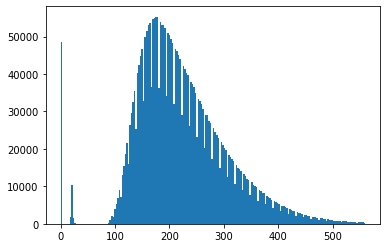

In [ ]:
insert_lengths = [read.template_length for read in reads]

plt.hist(insert_lengths, range=(0, 560), bins=200)
plt.show()

In [ ]:
!{picard} CollectInsertSizeMetrics I = {map_file}.sorted.bam O = isize_metrics.txt H = isize_histogram.pdf M=0.5

INFO	2021-05-31 16:09:58	CollectInsertSizeMetrics	

********** NOTE: Picard's command line syntax is changing.
**********
********** For more information, please see:
********** https://github.com/broadinstitute/picard/wiki/Command-Line-Syntax-Transition-For-Users-(Pre-Transition)
**********
********** The command line looks like this in the new syntax:
**********
**********    CollectInsertSizeMetrics -I data/sample_23.map.sorted.bam -O isize_metrics.txt -H isize_histogram.pdf -M 0.5
**********


16:09:59.015 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/content/tools/picard.jar!/com/intel/gkl/native/libgkl_compression.so
[Mon May 31 16:09:59 UTC 2021] CollectInsertSizeMetrics HISTOGRAM_FILE=isize_histogram.pdf MINIMUM_PCT=0.5 INPUT=data/sample_23.map.sorted.bam OUTPUT=isize_metrics.txt    DEVIATIONS=10.0 METRIC_ACCUMULATION_LEVEL=[ALL_READS] INCLUDE_DUPLICATES=false ASSUME_SORTED=true STOP_AFTER=0 VERBOSITY=INFO QUIET=false VALIDATION_STRINGENCY=STRICT COMP

3. Process the obtained BAM file according to the GATK protocol (Duplicate marking, recalibration of base quality) 

duplicates marking

In [ ]:
!{picard} MarkDuplicates I={map_file}.sorted.bam O={map_file}.dup.bam M={map_file}.dup.txt
!grep -A2 '## METRICS CLASS' {map_file}.dup.txt | grep -v '## METRICS CLASS' > report.tsv

INFO	2021-05-31 16:30:52	MarkDuplicates	

********** NOTE: Picard's command line syntax is changing.
**********
********** For more information, please see:
********** https://github.com/broadinstitute/picard/wiki/Command-Line-Syntax-Transition-For-Users-(Pre-Transition)
**********
********** The command line looks like this in the new syntax:
**********
**********    MarkDuplicates -I data/sample_23.map.sorted.bam -O data/sample_23.map.dup.bam -M data/sample_23.map.dup.txt
**********


16:30:53.268 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/content/tools/picard.jar!/com/intel/gkl/native/libgkl_compression.so
[Mon May 31 16:30:53 UTC 2021] MarkDuplicates INPUT=[data/sample_23.map.sorted.bam] OUTPUT=data/sample_23.map.dup.bam METRICS_FILE=data/sample_23.map.dup.txt    MAX_SEQUENCES_FOR_DISK_READ_ENDS_MAP=50000 MAX_FILE_HANDLES_FOR_READ_ENDS_MAP=8000 SORTING_COLLECTION_SIZE_RATIO=0.25 TAG_DUPLICATE_SET_MEMBERS=false REMOVE_SEQUENCING_DUPLICATES=false TAGGING

duplicates counting

In [ ]:
marked_duplicates = pysam.AlignmentFile(map_file + '.dup.bam')
dups_cnt = len([read for read in marked_duplicates if read.is_duplicate])

print('Duplicate reads: ' + str(dups_cnt))

Duplicate reads: 939342


3a. What are the estimated PCRs and optical duplicates?

In [ ]:
pd.read_csv('/content/drive/My Drive/bioinformatika/D2/report.tsv', sep='\t')

,LIBRARY,UNPAIRED_READS_EXAMINED,READ_PAIRS_EXAMINED,SECONDARY_OR_SUPPLEMENTARY_RDS,UNMAPPED_READS,UNPAIRED_READ_DUPLICATES,READ_PAIR_DUPLICATES,READ_PAIR_OPTICAL_DUPLICATES,PERCENT_DUPLICATION,ESTIMATED_LIBRARY_SIZE
0,Unknown Library,16292,2981677,5920,227056,9562,464890,0,0.15709,8539709


rekalibracija kvaliteta baza

In [ ]:
dbsnp_file = 'data/Homo_sapiens_assembly38.dbsnp138.vcf'

In [ ]:
!{picard} AddOrReplaceReadGroups I={map_file}.dup.bam O={map_file}.gr.dup.bam RGID=4 RGLB=lib1 RGPL=illumina RGPU=unit1 RGSM=20 

In [ ]:
!{gatk} BaseRecalibrator -I {map_file}.dup.bam --known-sites {dbsnp_file} -O {map_file}.cal.tbl --reference {genome_file}
!{gatk} ApplyBQSR -I {map_file}.gr.dup.bam -bqsr {map_file}.cal.tbl -O {map_file}.cal.bam

In [ ]:
!{gatk} BaseRecalibrator -I {map_file}.cal.bam --known-sites {dbsnp_file} -O {map_file}.post.cal.tbl --reference {genome_file}
!{gatk} AnalyzeCovariates -before {map_file}.cal.tbl -after {map_file}.post.cal.tbl -plots {map_file}.cmp.pdf

 4. Identify mutations using the Haplotype Caller tool and filter mutations with predefined filters (hard filtering) according to Broad recommendations. 

4a. How many mutations are identified in total, how many SNPs, how many INDELs? 

4b. How many mutations pass, and how many do not pass the filtering criteria? 

4c. Calculate Ti/Tv ratio before and after filtration.

In [ ]:
!{gatk} HaplotypeCaller --input {map_file}.cal.bam --output {map_file}.vcf --reference {genome_file} --dbsnp {dbsnp_file} -L chr11

helper functions

In [ ]:
def is_snp(variant):
    return len(variant.ref) == 1 and len(variant.alts[0]) == 1

def is_transitions(variant):
    allels = set((variant.ref, variant.alts[0]))
    return allels == {'A', 'G'} or allels == {'C', 'T'}

def is_filtered(variant):
    return 'PASS' not in variant.filter


snp and indel count, Ti/Tv before filtering

In [ ]:
vcf_variants = pysam.VariantFile(map_file + '.vcf')
variants = list(vcf_variants.fetch())

snp_count = sum(1 for v in variants if is_snp(v))
indel_count = len(variants) - snp_count

ti = sum(1 for v in variants if is_snp(v) and is_transitions(v))
tv = sum(1 for v in variants if is_snp(v) and not is_transitions(v))

print('Total number of variants: ', len(variants))
print('SNP: {} INDEL: {}'.format(snp_count, indel_count))
print('Ti/Tv ratio before filtering: ', ti/tv)


Total number of variants:  12059
SNP: 10702 INDEL: 1357
Ti/Tv ratio before filtering:  2.0121024486349564


hard filtering by Broad Institute recommendations

In [ ]:
snp_f = 'QD < 2.0 || FS > 60.0 || MQ < 40.0 || MQRankSum < -12.5 || ReadPosRankSum < -8.0'
indel_f = 'QD < 2.0 || FS > 200.0 || ReadPosRankSum < -20.0'

!{gatk} SelectVariants -R {genome_file} -V {map_file}.vcf -O {map_file}.snp.vcf --select-type-to-include SNP    # only snip-s
!{gatk} VariantFiltration -R {genome_file} -V {map_file}.snp.vcf -O {map_file}.snp.fil.vcf -filter '{snp_f}' --filter-name 'snp'
!{gatk} SelectVariants -R {genome_file} -V {map_file}.vcf -O {map_file}.ind.vcf --select-type-to-include INDEL  # only indel-s
!{gatk} VariantFiltration -R {genome_file} -V {map_file}.ind.vcf -O {map_file}.ind.fil.vcf -filter '{indel_f}' --filter-name 'indel'
!{gatk} MergeVcfs -I {map_file}.snp.fil.vcf -I {map_file}.ind.fil.vcf -O {map_file}.fil.vcf                     # merging 

In [ ]:
vcf_filtered = pysam.VariantFile(map_file + '.fil.vcf')
filtered = list(vcf_filtered.fetch())

total_failed = sum(1 for v in filtered if is_filtered(v))
failed_snp = sum(1 for v in filtered if is_filtered(v) and is_snp(v))
failed_indel =  sum(1 for v in filtered if is_filtered(v) and not is_snp(v))

ti = sum(1 for v in filtered if not is_filtered(v) and is_snp(v) and is_transitions(v))
tv = sum(1 for v in filtered if not is_filtered(v) and is_snp(v) and not is_transitions(v))

print('Total failed: ', total_failed)
print('Failed SNPs: ', failed_snp)
print('Failed INDELs: ', failed_indel)
print('Ti/Tv after filtering = {}'.format(ti/tv))

Total failed:  287
Failed SNPs:  216
Failed INDELs:  71
Ti/Tv after filtering = 2.0158227848101267


5. Annotate mutations with the Funcotator tool

In [ ]:
func_dir = 'funcotator_dataSources.v1.6.20190124g/'

In [ ]:
%cd {root_dir}
!{gatk} FuncotatorDataSourceDownloader --germline --extract-after-download
%cd {drive_dir}
!{gatk} Funcotator -O {map_file}.ann.vcf --ref-version hg38 -R {genome_file} -V {map_file}.fil.vcf --output-file-format VCF --data-sources-path {root_dir}{func_dir}

5a. Enumerate different values of ClinVar significance (annotation ClinVar_VCF_CLNSIG, how many mutations are marked as Benign, Likely_benign...)


In [ ]:
vcf_annotated = pysam.VariantFile(map_file + '.ann.vcf')
annotated = list(vcf_annotated.fetch())
description = vcf_annotated.header.info['FUNCOTATION'].description
functotations = description[73:].split('|')

labels = {}

for variant in annotated:
    ann = {x:y for x, y in zip(functotations, variant.info['FUNCOTATION'][0][1:-1].split('|'))}['ClinVar_VCF_CLNSIG']
    if ann:
        ann = ann.replace('_', ' ').replace(' %2C ', '').capitalize()
        if ann in labels:
            labels[ann] += 1
        else:
            labels[ann] = 1

for k, v in labels.items():
    print('{} : {}'.format(k, v))

Benign : 248
Benign/likely benign : 55
Uncertain significance : 5
Likely benign : 25
Not provided : 11
Benign/likely benign drug response risk factor : 1
Pathogenic : 1
Conflicting interpretations of pathogenicity affects : 1
Conflicting interpretations of pathogenicity : 2
Association : 1
Risk factor : 2
Drug response : 2
Protective : 1


6. All samples contain a certain amount of DNA contamination with material of bacterial or viral origin. Most of these reads will not be mapped to the human genome. Extract readings that are not mapped in the mapping process, assemble them with the abyss tool, and identify the organism from which the longest scaffold originates using the Blast tool.

In [ ]:
unmapped_file = root_dir + 'sample_23.unmap.bam'

In [ ]:
!samtools

In [ ]:
!samtools view -b -f 4 {map_file}.sorted.bam > {unmapped_file}

In [ ]:
!abyss-pe j=2 k=64 name={unmap_file}.bac in={unmapped_file}

ABYSS -k64 -q3    --coverage-hist=coverage.hist -s /content/sample_23.unmap.bam.bac-bubbles.fa  -o /content/sample_23.unmap.bam.bac-1.fa /content/sample_23.unmap.bam 
ABySS 2.0.2
ABYSS -k64 -q3 --coverage-hist=coverage.hist -s /content/sample_23.unmap.bam.bac-bubbles.fa -o /content/sample_23.unmap.bam.bac-1.fa /content/sample_23.unmap.bam
Reading `/content/sample_23.unmap.bam'...
`/content/sample_23.unmap.bam': discarded 17031 reads shorter than 64 bases
`/content/sample_23.unmap.bam': discarded 14 reads containing non-ACGT characters
Loaded 10435586 k-mer
Minimum k-mer coverage is 2
Using a coverage threshold of 2...
The median k-mer coverage is 6
The reconstruction is 4941127
The k-mer coverage threshold is 2.44949
Setting parameter e (erode) to 2
Setting parameter E (erodeStrand) to 1
Setting parameter c (coverage) to 2.44949
Generating adjacency
Added 20938003 edges.
Eroding tips
Eroded 3025736 tips.
Eroded 0 tips.
Pruning tips shorter than 1 bp...
Pruned 26 k-mer in 26 tips.
Pruni

In [ ]:
scaffold = pysam.FastaFile(unmap_file + '.bac-1.fa')
longest = sorted(zip(scaffold.lengths, scaffold.references), reverse=True)[0][1]

print(scaffold.fetch(longest))

GCACCAACACGCAGACGGCCTTGCTCGTCTTTACAGGCGTTCGGTTTACGTTCCGCTTTCTGGAAGTCTTTCACGGTGATCATGCCGATCAGGTGGAATTCGTCATCAACCACCAGCGCTTTTTCAACGCGTTTTTCGTGCATTTTTGCCAGCACCACTTCACGGGCTTCACCTTCACGCACGGTGACCAGACGCTCTTTCGGCGTCATGTAAACGCTAACCGGCTGGTTCAGGTCGGTAACAAAACGCACGTCACGACCGGTGATAATACCCACCAGTTCGTTTTCTTCGGTAACGACCGGATAGCCCGCAAAACCGTTACGCTCAGTCAGTTCTTTCACTTCGCGCAGCGTCGTGGTTGGCAGAACAGTCTGCGGATCAGTCACCACACCAGATTCGTGTTTTTTCACACGGCGAACTTCTTCTGCCTGGCGTTCAATGGACATGTTTTTGTGGATAAAGCCGATACCGCCTTCCTGAGCCAGAGCAATAGCCAGGCGCGCTTCCGTTACGGTATCCATTGCTGCGGAAAGCATAGGGATATTCAGACGAATAGTTTTCGTCAGCTGGGTGCTGAGGTCAGCAGTATTCGGCAGAACGGTAGAATGAGCAGGAACGAGGAGAACGTCGTCAAACGTCAGAGCTTCTTTAGCGATACGTAGCATGGGCAATATCTCGACCAGAGTGGTTAATAAATATTGCCGCGGCATTATACAGAGCGTAACCGATTGCATCTACCCCTTTTTGCAAAAAATGCTTGCTATCCCCGAAGGGCGGGTTACTATCGACTGAATAACCTGCTGATTTAGAATTTGATCTCGCTCACATGTTACCTTCTCAATCCCCTGCAATTTTTACCGTTAGTCGCCTGAATCAAACGGTTCGTCTGCTGCTTGAGCATGAGATGGGACAGGTTTGGATCAGCGGCGAAATCTCTAATTTCACACAACCGGCTTCCGGTCACTGGTACTTTACACTCAAAGACGACACCGCCCAGGTA

E. Coli https://www.ncbi.nlm.nih.gov/Taxonomy/Browser/wwwtax.cgi?id=1055537